### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading Cleaned Dataset

In [5]:
df_cleaned_transaction_data = pd.read_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\Cleaned_Finlora_Dataset.parquet")

### Setting a Consistent Visualisation Theme

In [20]:
# Set a clean, professional theme
sns.set_theme(
    style="white",
    context="notebook",
    font_scale=1.1
)

# Create a readable label column for is_fraud
df_cleaned_transaction_data["fraud_label"] = df_cleaned_transaction_data["is_fraud"].map({
    0: "Legitimate",
    1: "Fraud"
})

# Consistent color mapping for fraud analysis
fraud_palette = {
    "Legitimate": "#2E75B6",   # blue - calm/normal
    "Fraud": "#C0392B"         # red - alert/risk
}

# General palette for non-fraud-specific categorical plots (channel, currency, etc.)
sns.set_palette(["#2E75B6", "#C0392B", "#59A14F", "#F4A261", "#8E7CC3", "#4C4C4C"])

### 1. The Fraud Landscape - Baseline Understanding
Establishing the scale of the problem before digging into drivers.

In [15]:
# Question 1 - How many customers and transactions are we looking at?

print(f"There are {df_cleaned_transaction_data["customer_id"].nunique()} customers and {df_cleaned_transaction_data["transaction_id"].nunique()} transactions represented in this dataset")

There are 1314 customers and 10940 transactions represented in this dataset


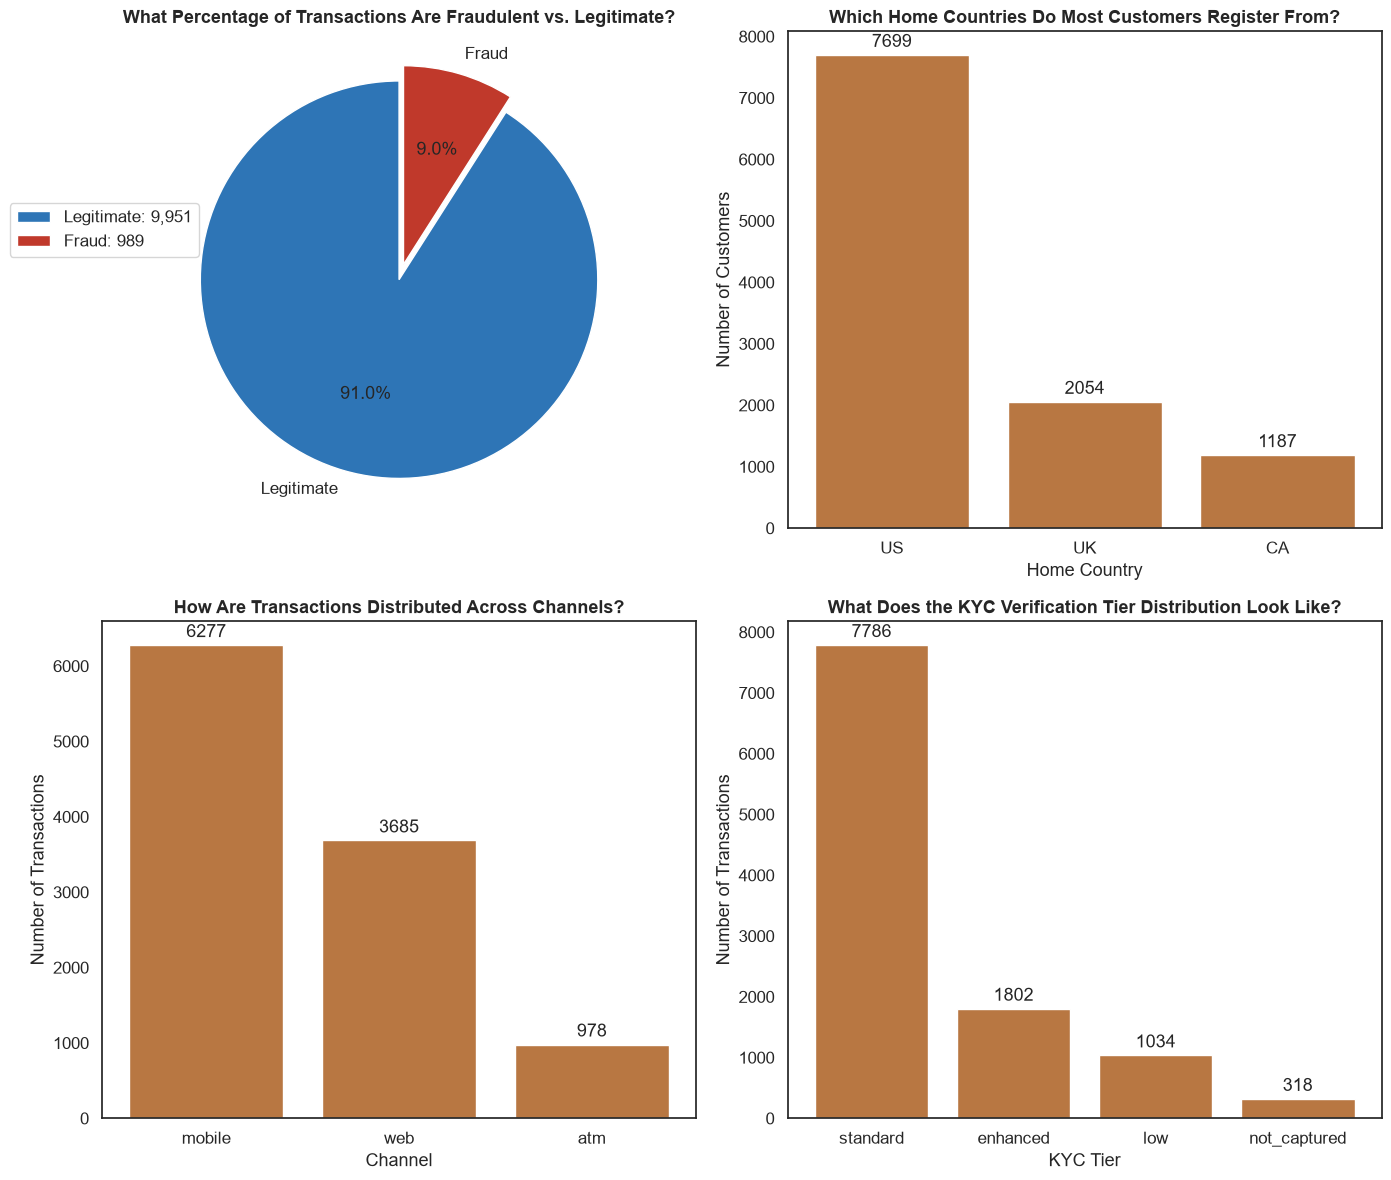

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Q2: What percentage of transactions are fraudulent vs. legitimate?
fraud_counts = df_cleaned_transaction_data["fraud_label"].value_counts()

wedges, texts, autotexts = axes[0].pie(
    fraud_counts,
    labels=fraud_counts.index,
    autopct="%1.1f%%",
    colors=[fraud_palette[label] for label in fraud_counts.index],
    startangle=90,
    explode=[0, 0.08]
)
axes[0].set_title("What Percentage of Transactions Are Fraudulent vs. Legitimate?")
axes[0].legend(
    wedges,
    [f"{label}: {count:,}" for label, count in fraud_counts.items()],
    loc="center left",
    bbox_to_anchor=(-0.3, 0.6)
)

# Q3: Which home countries do most customers register from?
country_counts = df_cleaned_transaction_data["home_country"].value_counts()
bars = axes[1].bar(country_counts.index, country_counts.values, color="#B87742")
axes[1].bar_label(bars, fmt="%d", padding=3)
axes[1].set_title("Which Home Countries Do Most Customers Register From?")
axes[1].set_xlabel("Home Country")
axes[1].set_ylabel("Number of Customers")

# Q4: How are transactions distributed across channels?
channel_counts = df_cleaned_transaction_data["channel"].value_counts()
bars = axes[2].bar(channel_counts.index, channel_counts.values, color="#B87742")
axes[2].bar_label(bars, fmt="%d", padding=3)
axes[2].set_title("How Are Transactions Distributed Across Channels?")
axes[2].set_xlabel("Channel")
axes[2].set_ylabel("Number of Transactions")

# Q5: What does the KYC verification tier distribution look like?
kyc_counts = df_cleaned_transaction_data["kyc_tier"].value_counts()
bars = axes[3].bar(kyc_counts.index, kyc_counts.values, color="#B87742")
axes[3].bar_label(bars, fmt="%d", padding=3)
axes[3].set_title("What Does the KYC Verification Tier Distribution Look Like?")
axes[3].set_xlabel("KYC Tier")
axes[3].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

With 1,314 customers and 10,940 transactions in the cleaned dataset, this section establishes the baseline before digging into what drives fraud.

**Fraud is rare but material.** Fraudulent transactions make up **9.0%** of the dataset (989 of 10,940), against 91.0% legitimate. This confirms the class imbalance flagged in the project scope and will shape the modelling and evaluation approach going forward.

**Customers are concentrated in the US.** The majority of customers registered their account in the **US** (7,699), followed by the **UK** (2,054) and **CA** (1,187) — a skew worth keeping in mind when interpreting any geography-based fraud patterns later.

**Mobile is the dominant channel.** Most transactions occur via **mobile** (6,277), followed by **web** (3,685), with **ATM** transactions making up the smallest share (978).

**Most customers are standard-tier verified.** The majority of transactions come from **standard** KYC customers (7,786), with far fewer at **enhanced** (1,802) and **low** (1,034) tiers. Only **318** transactions fall under the **not_captured** placeholder, confirming this group is a small minority of the overall dataset.

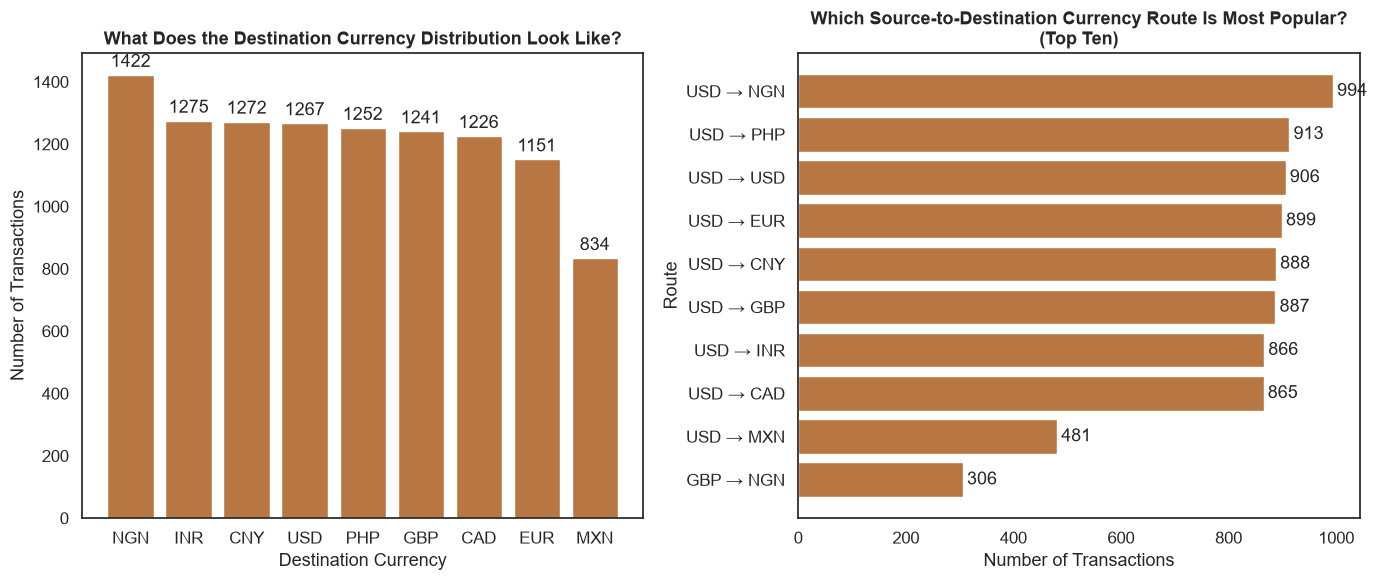

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Q6: What does the destination currency distribution look like?
dest_counts = df_cleaned_transaction_data["dest_currency"].value_counts()
bars = axes[0].bar(dest_counts.index, dest_counts.values, color="#B87742")
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("What Does the Destination Currency Distribution Look Like?")
axes[0].set_xlabel("Destination Currency")
axes[0].set_ylabel("Number of Transactions")

# Q7: Which source-to-destination currency route is most popular?
df_cleaned_transaction_data["currency_route"] = (
    df_cleaned_transaction_data["source_currency"] + " → " + df_cleaned_transaction_data["dest_currency"]
)
route_counts = df_cleaned_transaction_data["currency_route"].value_counts().head(10)  # top 10
bars = axes[1].barh(route_counts.index[::-1], route_counts.values[::-1], color="#B87742")
axes[1].bar_label(bars, fmt="%d", padding=3)
axes[1].set_title("Which Source-to-Destination Currency Route Is Most Popular?\n(Top Ten)")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Route")

plt.tight_layout()
plt.show()

Destination currencies are fairly evenly spread, with **NGN** the most common (1,422) and **MXN** the least (834) — no single destination dominates.

The route breakdown shows **USD as the almost exclusive source currency** among the top 10 routes, with **USD → NGN** the most popular corridor (994 transactions). The one exception, **GBP → NGN** (306), still points to NGN as a consistently popular destination regardless of source currency.

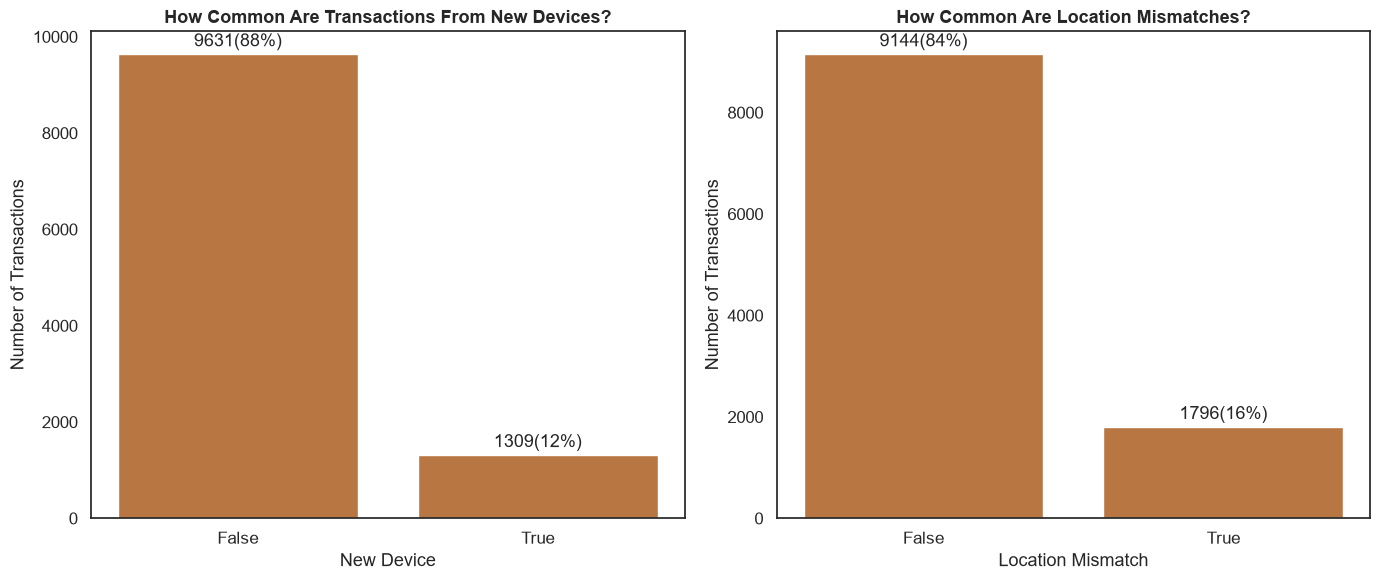

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes = axes.flatten()

# Q8: How common are transactions from new devices?
new_device_counts = df_cleaned_transaction_data["new_device"].value_counts()
new_device_pct = df_cleaned_transaction_data["new_device"].value_counts(normalize=True) * 100

bars = axes[0].bar(new_device_counts.index.astype(str), new_device_counts.values, color="#B87742")
labels = [f"{count}({pct:.0f}%)" for count, pct in zip(new_device_counts.values, new_device_pct.values)]
axes[0].bar_label(bars, labels=labels, padding=3)
axes[0].set_title("How Common Are Transactions From New Devices?")
axes[0].set_xlabel("New Device")
axes[0].set_ylabel("Number of Transactions")

# Q9: How common are location mismatches?
mismatch_counts = df_cleaned_transaction_data["location_mismatch"].value_counts()
mismatch_pct = df_cleaned_transaction_data["location_mismatch"].value_counts(normalize=True) * 100

bars = axes[1].bar(mismatch_counts.index.astype(str), mismatch_counts.values, color="#B87742")
labels = [f"{count}({pct:.0f}%)" for count, pct in zip(mismatch_counts.values, mismatch_pct.values)]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].set_title("How Common Are Location Mismatches?")
axes[1].set_xlabel("Location Mismatch")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Most transactions come from **recognized devices** (88%) and **matching locations** (84%), meaning both risk indicators are relatively rare occurrences overall — new devices appear in only **12%** of transactions, and location mismatches in **16%**.

Since these signals are uncommon at the baseline level, their real value will show up in the next section: whether transactions carrying these flags are disproportionately associated with fraud.

In [47]:
def plot_distribution_grid(df, features, color="#B87742"):
    fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        hist_ax = axes[i * 2]
        box_ax = axes[i * 2 + 1]

        # Histogram
        hist_ax.hist(df[feature], bins=40, color=color, edgecolor="white")
        hist_ax.set_title(f"What Does the Distribution of {feature} Look Like?")
        hist_ax.set_xlabel(feature)
        hist_ax.set_ylabel("Count")

        # Boxplot
        box_ax.boxplot(df[feature], orientation="vertical", patch_artist=True,
                        boxprops=dict(facecolor=color, color="black"),
                        medianprops=dict(color="black"))
        box_ax.set_title(f"What Is the Spread of {feature}?")
        box_ax.set_xticks([])
        box_ax.set_ylabel(feature)

    plt.tight_layout()
    plt.show()

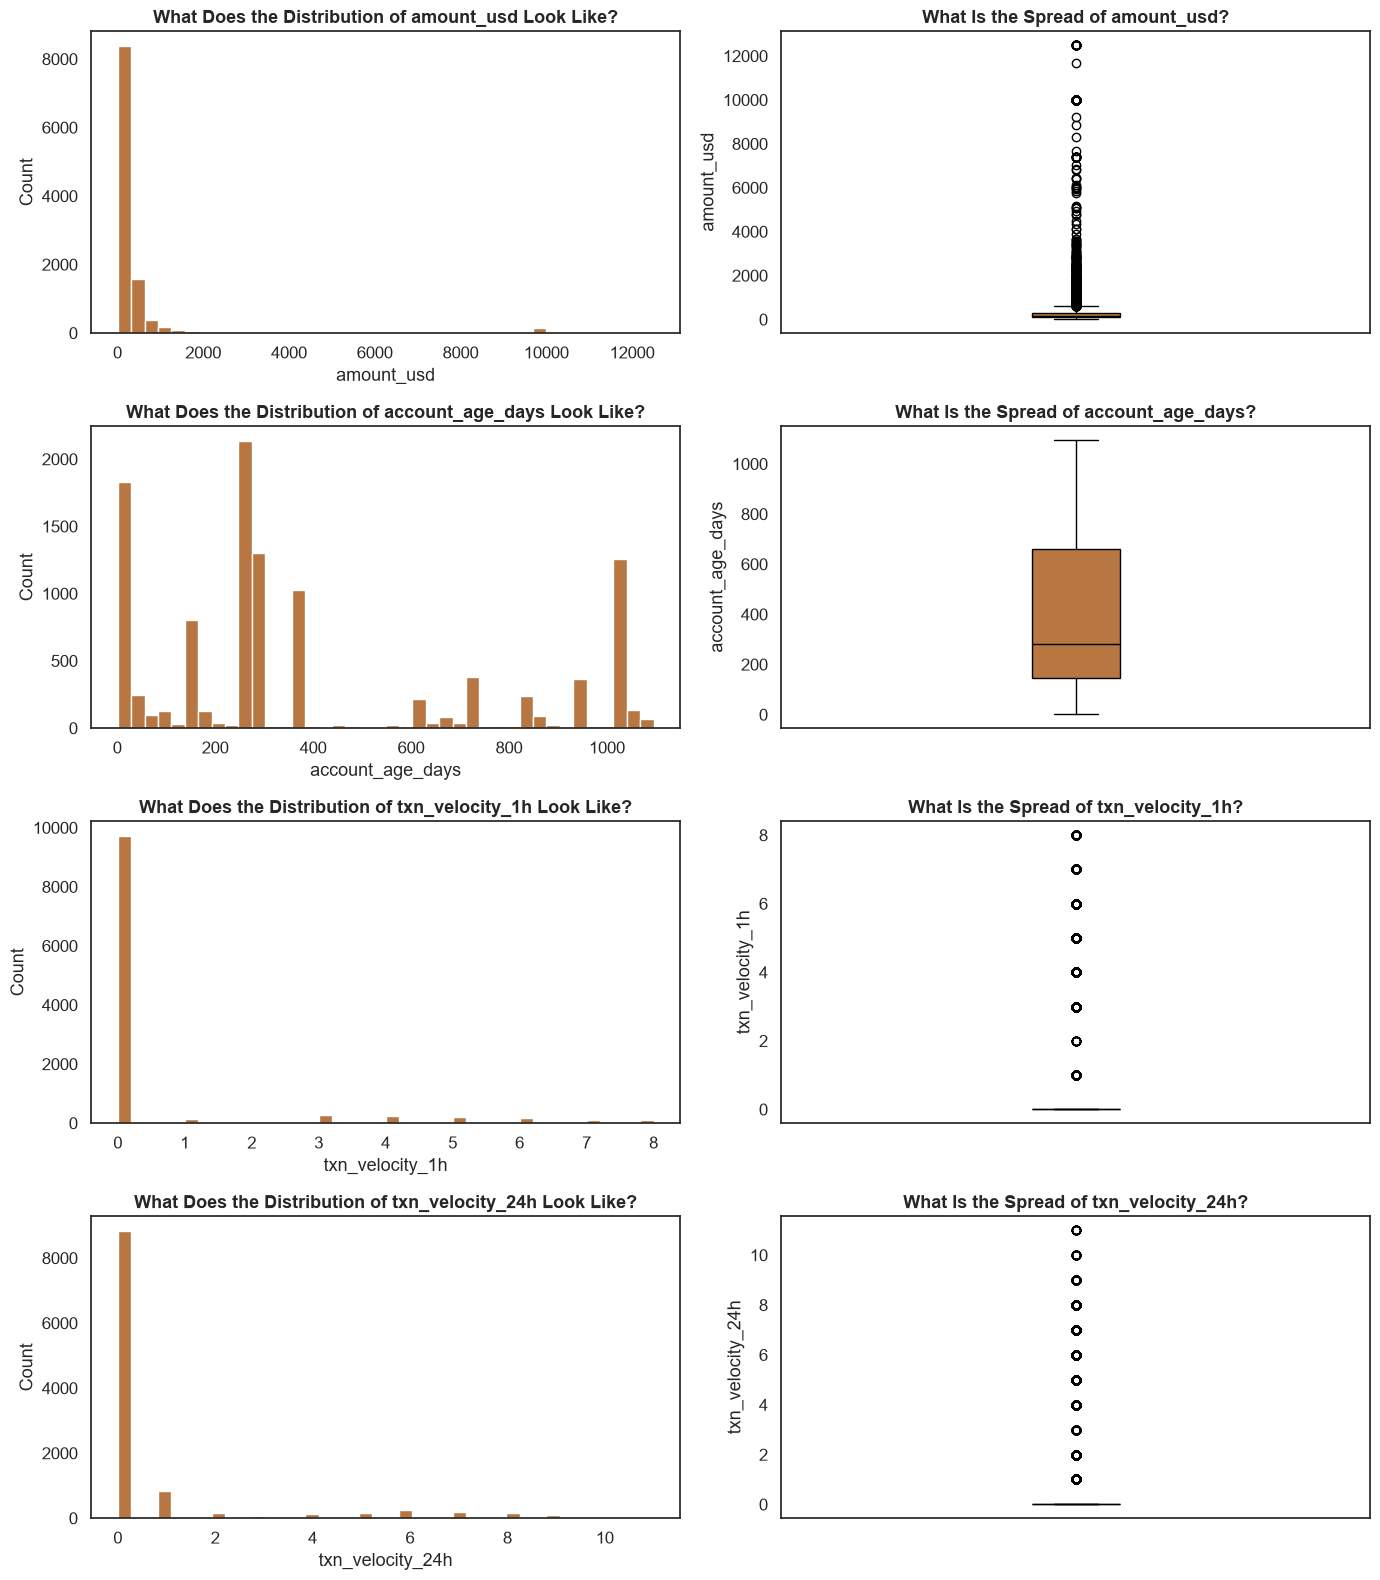

In [48]:
transaction_features = ["amount_usd", "account_age_days", "txn_velocity_1h", "txn_velocity_24h"]
plot_distribution_grid(df_cleaned_transaction_data, transaction_features)

##### Transaction Behavior: Amount, Account Age & Velocity

**Most transactions are small, but a few are very large.** Half of all transactions fall between **$93 and $303**, with a typical (median) transaction of about **$164** — but some transactions run as high as **$12,499**, showing up as a long tail of unusually large payments.

**Customers fall into a few distinct age groups rather than a smooth spread** — there are noticeable clusters of newer accounts, mid-tenure accounts (around 250-300 days old), and long-standing accounts (over 1,000 days), rather than customers being evenly spread across all account ages.

**The vast majority of customers make just one transaction at a time** — no other activity in the same hour or day. Only a small number of transactions happen back-to-back in quick succession, which stands out as unusual behavior worth watching closely once we compare it against fraud cases.

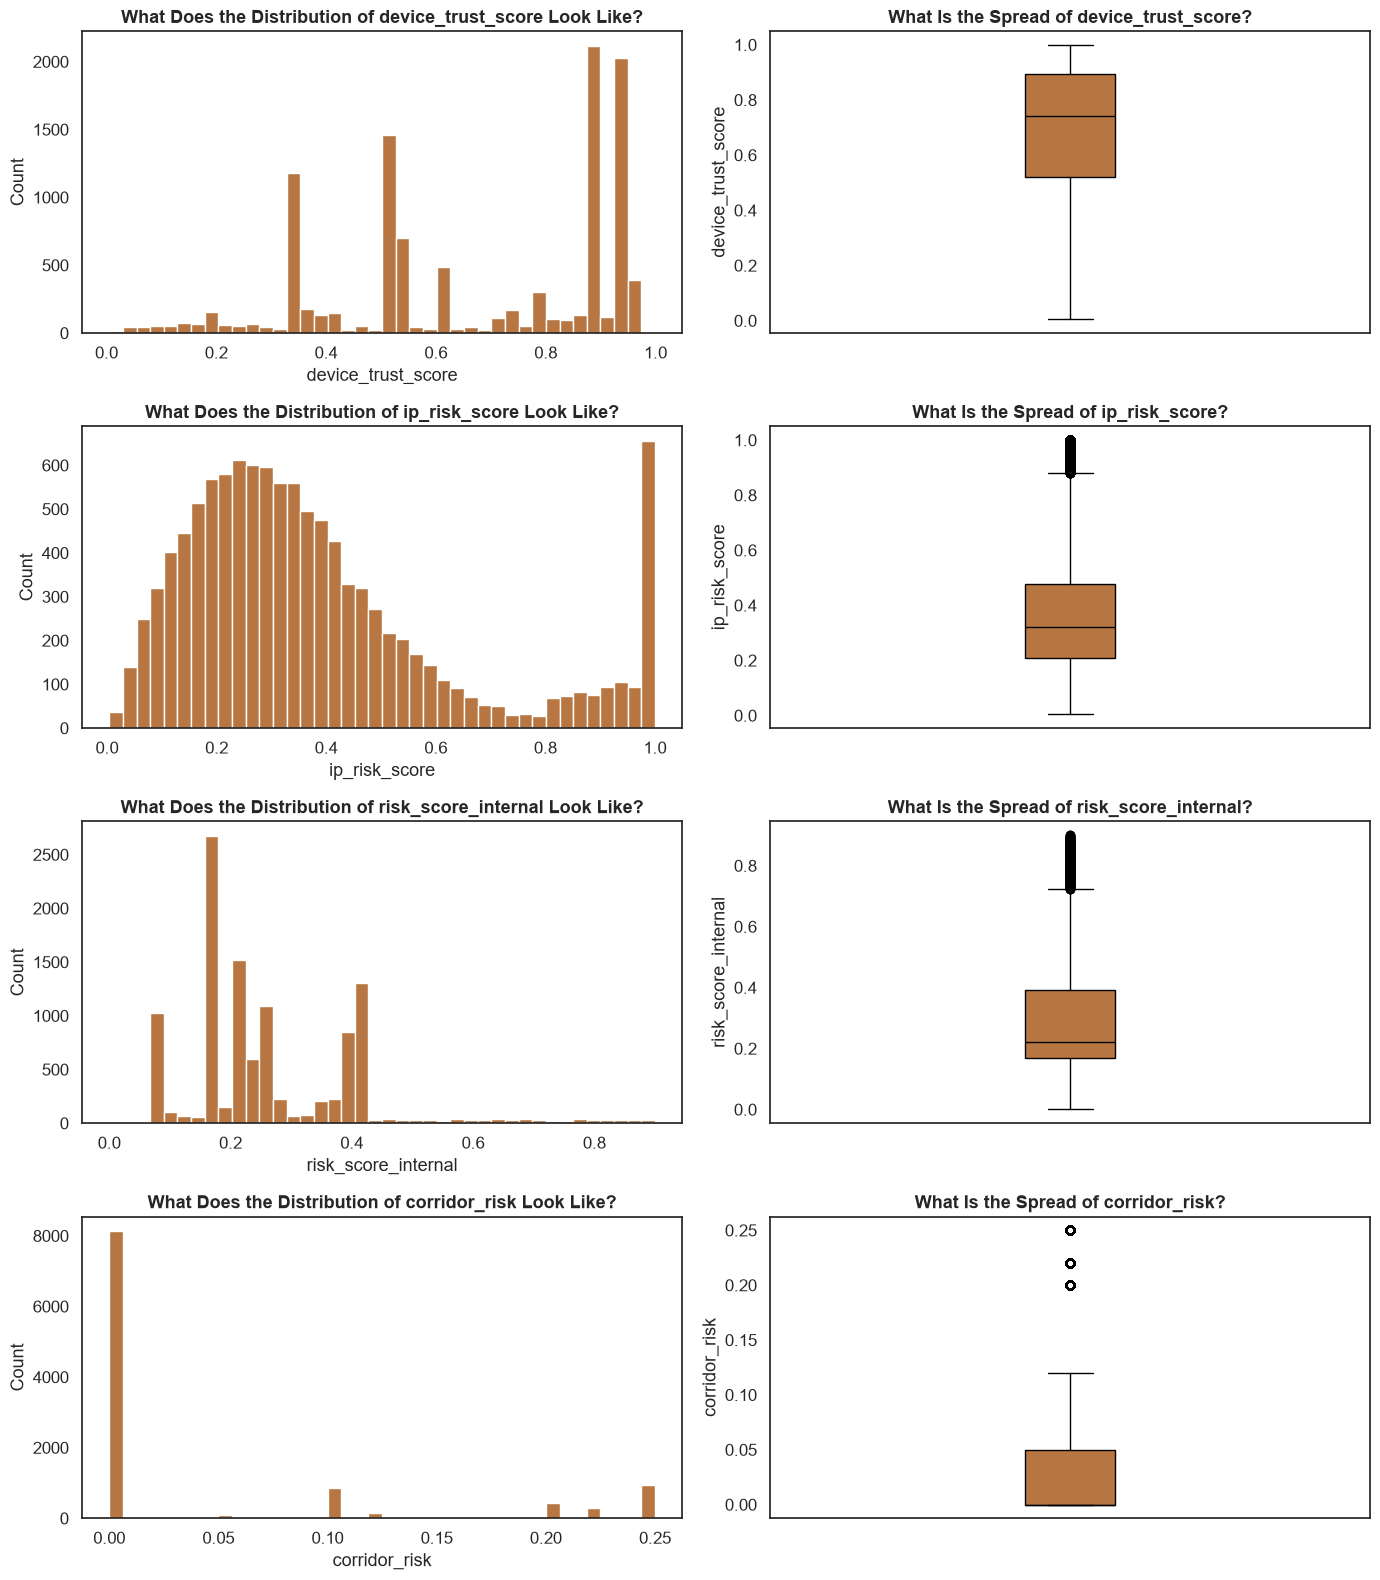

In [49]:
risk_features = ["device_trust_score", "ip_risk_score", "risk_score_internal", "corridor_risk"]
plot_distribution_grid(df_cleaned_transaction_data, risk_features)

##### Existing Risk Signals: Trust & Risk Scores

**Device trust score** reflects how much FinLora's system already trusts the device being used for a transaction, based on its history. Scores cluster around a few common values rather than spreading smoothly — most devices land either fairly high (around 0.9, indicating well-established, trusted devices) or moderately (around 0.5-0.6). Half of all devices score between **0.52 and 0.89**, suggesting devices tend to fall into a handful of trust tiers rather than being scored individually.

**IP risk score** flags how suspicious the location a transaction is coming from looks — based on signals like VPN use, proxies, or IPs previously linked to bad behavior. Most scores follow a natural spread, but there's a distinct spike of transactions scoring close to the maximum (near 1.0) — a small but clear group of highly suspicious origin locations sitting apart from the rest.

**Internal risk score** is FinLora's existing rule-based fraud score, so this tells us how the current system already rates each transaction before any new model gets involved. Most scores are low, with half of all transactions scoring below **0.22** — but a visible group of outliers scores much higher (above 0.7), standing out clearly in the boxplot.

**Corridor risk** captures how risky a specific money-transfer route (source-to-destination combination) has historically been — some country/currency pairings are simply more prone to fraud than others. This score is overwhelmingly zero for most transactions, meaning most routes are considered safe by default. A small number of specific corridors carry a distinctly higher risk score (up to 0.25), standing out as the exception rather than the norm.

Taken together, these are the risk signals FinLora already has in place — the next step is checking how well they actually line up with confirmed fraud cases.

### 2. Which Channels and Payment Routes Carry the Most Fraud Risk?

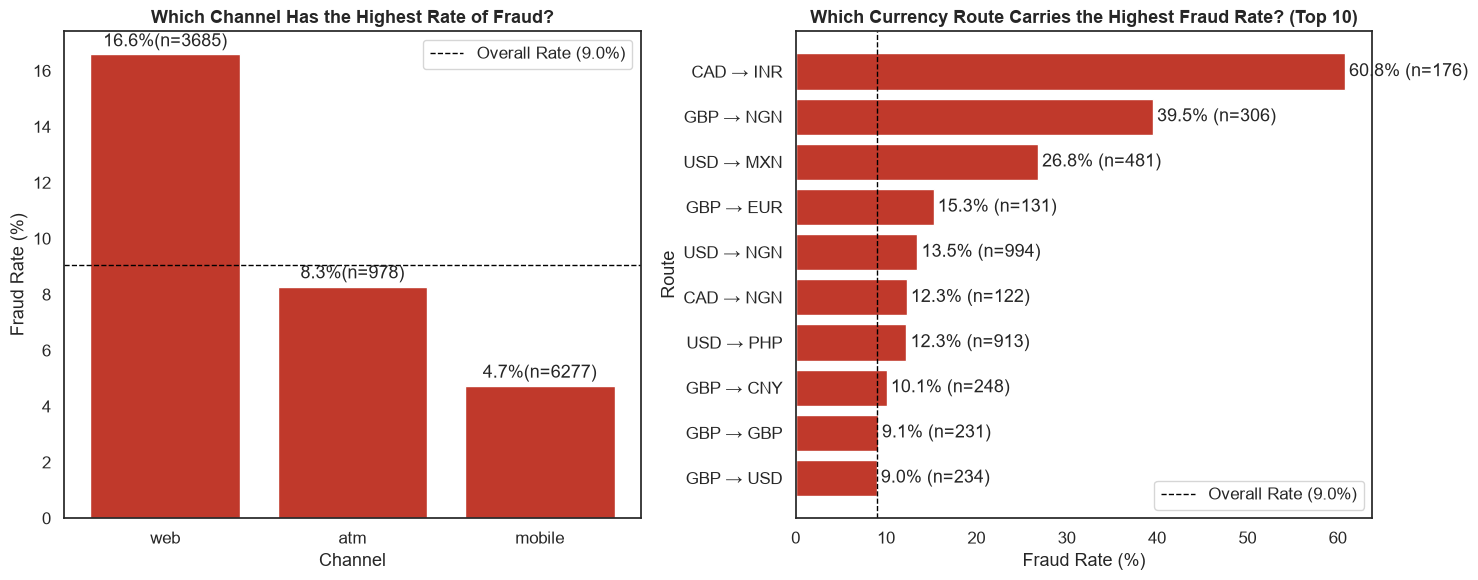

In [55]:
def fraud_rate_by_category(df, category_col, top_n=None):
    grouped = df.groupby(category_col)["is_fraud"].agg(["mean", "count"])
    grouped["fraud_rate_pct"] = grouped["mean"] * 100
    grouped = grouped.sort_values("fraud_rate_pct", ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    return grouped

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

# Q: Which channel has the highest rate of fraud, not just the most transactions?
channel_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "channel")
bars = axes[0].bar(channel_fraud.index, channel_fraud["fraud_rate_pct"], color="#C0392B")
labels = [f"{rate:.1f}%(n={count})" for rate, count in zip(channel_fraud["fraud_rate_pct"], channel_fraud["count"])]
axes[0].bar_label(bars, labels=labels, padding=3)
overall_rate = df_cleaned_transaction_data["is_fraud"].mean() * 100
axes[0].axhline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[0].set_title("Which Channel Has the Highest Rate of Fraud?")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

# Q: Which source-to-destination currency route carries the highest fraud rate?
route_fraud = fraud_rate_by_category(df_cleaned_transaction_data, "currency_route", top_n=10)
bars = axes[1].barh(route_fraud.index[::-1], route_fraud["fraud_rate_pct"][::-1], color="#C0392B")
labels = [f"{rate:.1f}% (n={count})" for rate, count in zip(route_fraud["fraud_rate_pct"][::-1], route_fraud["count"][::-1])]
axes[1].bar_label(bars, labels=labels, padding=3)
axes[1].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall Rate ({overall_rate:.1f}%)")
axes[1].set_title("Which Currency Route Carries the Highest Fraud Rate? (Top 10)")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("Route")
axes[1].legend()

plt.tight_layout()
plt.show()

**Web transactions are disproportionately risky.** Despite carrying less volume than mobile, **web** has a fraud rate of **16.6%** — nearly double the overall fraudulent rate of 9.0%. **Mobile**, by contrast, sits well below average at **4.7%**, despite handling the most transactions overall. This suggests fraud risk depends far more on *which channel* is used than on how much volume passes through it.

**A small number of currency routes carry extreme fraud risk.** The **CAD → INR** corridor stands out sharply, with **60.8%** of its transactions flagged as fraudulent — more than 6x the overall rate. **GBP → NGN** (39.5%) and **USD → MXN** (26.8%) also show fraud rates well above baseline. Most other routes hover close to or below the 9.0% average.

**Sample size matters here.** Some of the highest-risk routes involve relatively few transactions (e.g., CAD → INR at n=176, GBP → EUR at n=131), so while the pattern is worth flagging, these rates are based on smaller samples and should be treated as a strong signal to investigate further — not a fully confirmed pattern — compared to higher-volume routes like USD → NGN (n=994).